# W1-18 — Data and indicator validation

This notebook independently validates the saved QuantDash features for **AAPL** and **SPY**. It checks data quality, formulas, warm-up behavior, and symbol isolation.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

prices = pd.read_parquet(ROOT / 'data/processed/prices_clean.parquet')
features = pd.read_parquet(ROOT / 'data/processed/price_features.parquet')
SYMBOLS = ['AAPL', 'SPY']
sample = features[features.symbol.isin(SYMBOLS)].sort_values(['symbol', 'date']).copy()
sample.shape

(1012, 17)

## 1. Coverage and structural quality

In [2]:
quality = sample.groupby('symbol').agg(
    rows=('date', 'size'), first_date=('date', 'min'), last_date=('date', 'max'),
    missing_close=('close', lambda s: s.isna().sum()),
    missing_return=('simple_return', lambda s: s.isna().sum()),
    missing_sma20=('sma_20', lambda s: s.isna().sum()),
    missing_sma50=('sma_50', lambda s: s.isna().sum()),
    missing_rsi=('rsi_14', lambda s: s.isna().sum()),
    missing_volatility=('volatility_20d_annualized', lambda s: s.isna().sum()),
)
quality['duplicate_dates'] = sample.groupby('symbol').apply(lambda g: g.date.duplicated().sum(), include_groups=False)
quality

,rows,first_date,last_date,missing_close,missing_return,missing_sma20,missing_sma50,missing_rsi,missing_volatility,duplicate_dates
symbol,,,,,,,,,,
AAPL,506,2024-07-29,2026-08-04,0,1,19,49,14,20,0
SPY,506,2024-07-29,2026-08-04,0,1,19,49,14,20,0


## 2. Independent formula recomputation

In [3]:
def reference_rsi(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0).to_numpy()
    loss = (-delta.clip(upper=0)).to_numpy()
    out = np.full(len(close), np.nan)
    avg_gain, avg_loss = np.nanmean(gain[1:period+1]), np.nanmean(loss[1:period+1])
    for i in range(period, len(close)):
        if i > period:
            avg_gain = ((period - 1) * avg_gain + gain[i]) / period
            avg_loss = ((period - 1) * avg_loss + loss[i]) / period
        out[i] = 50 if avg_gain == avg_loss == 0 else (100 if avg_loss == 0 else (0 if avg_gain == 0 else 100 - 100/(1 + avg_gain/avg_loss)))
    return pd.Series(out, index=close.index)

def validate_symbol(group):
    g = group.sort_values('date').copy()
    close = g.close
    log_return = np.log(close).diff()
    expected = {
        'simple_return': close.pct_change(fill_method=None),
        'log_return': log_return,
        'sma_20': close.rolling(20, min_periods=20).mean(),
        'sma_50': close.rolling(50, min_periods=50).mean(),
        'ema_20': close.ewm(span=20, adjust=False, min_periods=20).mean(),
        'rsi_14': reference_rsi(close),
        'volatility_20d_annualized': log_return.rolling(20, min_periods=20).std(ddof=1) * np.sqrt(252),
        'drawdown': close / close.cummax() - 1,
    }
    expected['max_drawdown_to_date'] = expected['drawdown'].cummin()
    rows = []
    for column, reference in expected.items():
        difference = (g[column] - reference).abs()
        rows.append({'indicator': column, 'passed': np.allclose(g[column], reference, equal_nan=True, rtol=1e-10, atol=1e-12), 'max_abs_error': difference.max(skipna=True)})
    return pd.DataFrame(rows)

validation = pd.concat({symbol: validate_symbol(sample[sample.symbol.eq(symbol)]) for symbol in SYMBOLS}, names=['symbol'])
validation.reset_index(level=1, drop=True).reset_index()

,symbol,indicator,passed,max_abs_error
0,AAPL,simple_return,True,0.0
1,AAPL,log_return,True,0.0
2,AAPL,sma_20,True,0.0
3,AAPL,sma_50,True,0.0
4,AAPL,ema_20,True,0.0
5,AAPL,rsi_14,True,0.0
6,AAPL,volatility_20d_annualized,True,0.0
7,AAPL,drawdown,True,0.0
8,AAPL,max_drawdown_to_date,True,0.0
9,SPY,simple_return,True,0.0


In [4]:
assert validation['passed'].all(), validation[~validation.passed]
assert sample.rsi_14.dropna().between(0, 100).all()
assert sample.drawdown.between(-1, 0).all()
assert not sample.duplicated(['symbol', 'date']).any()
print(f'PASS: all {len(validation)} indicator/symbol comparisons matched.')

PASS: all 18 indicator/symbol comparisons matched.


## 3. Visual inspection

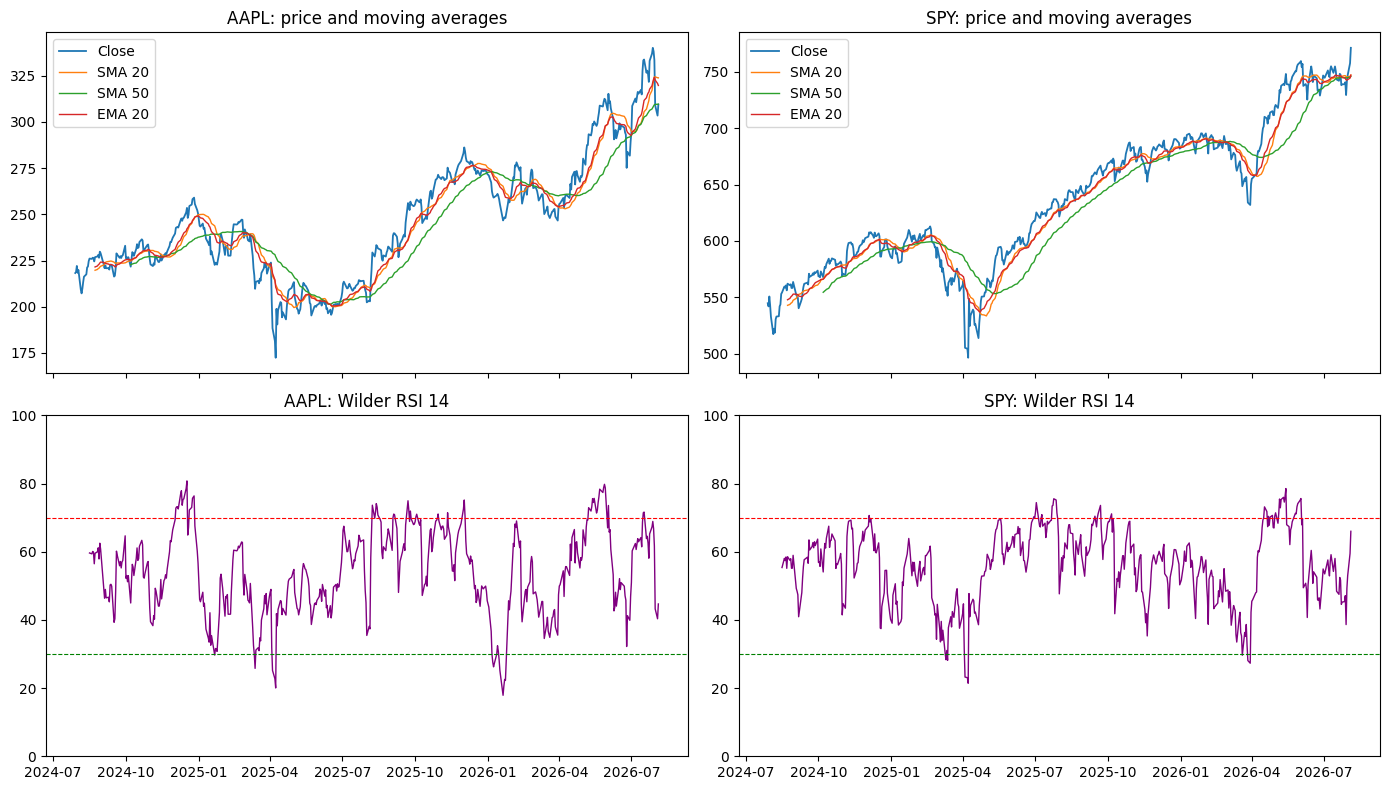

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col')
for column, symbol in enumerate(SYMBOLS):
    g = sample[sample.symbol.eq(symbol)]
    axes[0, column].plot(g.date, g.close, label='Close', linewidth=1.3)
    axes[0, column].plot(g.date, g.sma_20, label='SMA 20', linewidth=1)
    axes[0, column].plot(g.date, g.sma_50, label='SMA 50', linewidth=1)
    axes[0, column].plot(g.date, g.ema_20, label='EMA 20', linewidth=1)
    axes[0, column].set_title(f'{symbol}: price and moving averages')
    axes[0, column].legend()
    axes[1, column].plot(g.date, g.rsi_14, color='purple', linewidth=1)
    axes[1, column].axhline(70, color='red', linestyle='--', linewidth=.8)
    axes[1, column].axhline(30, color='green', linestyle='--', linewidth=.8)
    axes[1, column].set_ylim(0, 100)
    axes[1, column].set_title(f'{symbol}: Wilder RSI 14')
fig.tight_layout()
plt.show()

## Conclusion

The notebook passes only if all nine saved indicators match independent recomputations for both AAPL and SPY. Warm-up nulls are expected mathematical results, not missing-data defects.